In [283]:
!pip install photutils #only needed if its being run on colabs
import os
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
from scipy import ndimage
import matplotlib.pyplot as plt
from photutils.centroids import centroid_com
from photutils.isophote import EllipseGeometry
from photutils.aperture import EllipticalAperture
from photutils.isophote import Ellipse
from photutils.aperture import aperture_photometry

In [284]:
paths = {
    'R': 'm57_red_bkg/m57_red_bkg.fits',
    'V': 'm57_green_bkg/m57_green_bkg.fits',
    'B': 'm57_blue_bkg/m57_blue_bkg.fits'
}

# output folder
out_dir = 'm57_surface_photometry'
os.makedirs(out_dir, exist_ok=True)

# quick check
for filt, p in paths.items():
    print(filt, ':', 'FOUND' if os.path.exists(p) else 'MISSING ->', p)

R : FOUND m57_red_bkg/m57_red_bkg.fits
V : FOUND m57_green_bkg/m57_green_bkg.fits
B : FOUND m57_blue_bkg/m57_blue_bkg.fits


In [285]:
def load_fits(path):
    hdul = fits.open(path)
    data = hdul[0].data.astype(float)
    header = hdul[0].header
    wcs = None
    try:
        wcs = WCS(header)
    except Exception:
        wcs = None
    return data, header, wcs

def print_header_keys(path, n=40):
    _, header, _ = load_fits(path)
    keys = list(header.keys())
    print(f'Header keys (first {n}):')
    for k in keys[:n]:
        print(k, header[k])
    # print full header optionally
    return header

def guess_pixel_scale_arcsec(header, wcs=None):
    """Try common header keys and WCS to estimate arcsec/pixel. Return None if not found."""
    # common keywords that might store scale in arcsec/pixel
    for key in ('PIXSCALE','PIXSCALE1','PIXSCL','PLATESCALE','PIXSIZE'):
        if key in header:
            try:
                val = float(header[key])
                return val
            except Exception:
                pass
    # try WCS: proj_plane_pixel_scales -> degrees/pixel
    if wcs is not None:
        try:
            scales_deg = proj_plane_pixel_scales(wcs)
            arcsec = np.median(scales_deg) * 3600.0
            return float(arcsec)
        except Exception:
            pass
    # try CDELT or CD keywords (degrees/pixel)
    for k in ('CDELT1','CD1_1','CD1_2'):
        if k in header:
            try:
                val = abs(float(header[k])) * 3600.0
                return val
            except Exception:
                pass
    return None

def guess_exptime(header):
    for key in ('EXPTIME','EXPOSURE','EXPOSURE_TIME','EXPT'):
        if key in header:
            try:
                return float(header[key])
            except Exception:
                pass
    return None

def guess_zeropoint(header):
    for key in ('ZP','MAGZP','ZEROPOINT','PHOTZP','MAGZERO','ZMAG'):
        if key in header:
            try:
                return float(header[key])
            except Exception:
                pass
    return None

In [286]:
# radial profile and 2D conversion utilities
def radial_profile(data, center, nbins=200, rmax=None, statistic='median'):
    """Compute radial profile (bins in pixels) around center = (x0, y0)."""
    y, x = np.indices(data.shape)
    x0, y0 = center
    r = np.hypot(x - x0, y - y0)
    if rmax is None:
        rmax = np.nanmax(r)
    bins = np.linspace(0.0, rmax, nbins+1)
    bin_centers = 0.5*(bins[:-1]+bins[1:])
    inds = np.digitize(r.flat, bins) - 1
    prof = np.full(nbins, np.nan)
    counts = np.zeros(nbins, dtype=int)
    flat = data.flat
    for i in range(nbins):
        sel = inds == i
        if not np.any(sel):
            continue
        vals = np.array(flat)[sel]
        vals = vals[~np.isnan(vals)]
        if vals.size == 0:
            continue
        counts[i] = vals.size
        prof[i] = np.median(vals) if statistic == 'median' else np.mean(vals)
    return bin_centers, prof, counts

def flux_to_mag_per_pixel(flux, zeropoint=None, exptime=None):
    """Convert positive flux (ADU) to mag/pixel given zeropoint. Returns np.nan where flux<=0."""
    arr = np.array(flux, dtype=float)
    arr[arr <= 0] = np.nan
    if zeropoint is None:
        return None
    if exptime:
        phot = arr / exptime
    else:
        phot = arr
    with np.errstate(divide='ignore', invalid='ignore'):
        magpix = -2.5 * np.log10(phot) + zeropoint
    return magpix

def magpix_to_mag_arcsec2(magpix, pixel_scale_arcsec):
    """Convert mag/pixel -> mag/arcsec^2: add 2.5*log10(pixel_area)"""
    if pixel_scale_arcsec is None:
        return None
    pix_area = (pixel_scale_arcsec**2)
    return magpix + 2.5 * np.log10(pix_area)

In [287]:
# center finding  - no need, we already have the coords for the center
def find_center(data, method='centroid', mask_fraction=0.995):
    """
    Find center of nebulosity.
    - method 'centroid': centroid of clipped bright region
    - fallback: image center
    """
    # smooth to avoid small noise peaks
    blur = ndimage.gaussian_filter(data, sigma=3)
    # mask top X percentile to isolate bright object
    thresh = np.nanpercentile(blur, 99.5)  # adjust if needed
    mask = blur >= thresh
    if np.sum(mask) < 10:
        # fallback to center of mass on positive clipped data
        clipped = np.nan_to_num(np.clip(data, a_min=0, a_max=None))
        try:
            cy, cx = ndimage.center_of_mass(clipped)
            return (cx, cy)
        except Exception:
            # image center fallback
            return (data.shape[1]/2.0, data.shape[0]/2.0)
    yidx, xidx = np.where(mask)
    return (np.mean(xidx), np.mean(yidx))

In [288]:
# this is just to inspect headers
for filt, p in paths.items():
    if os.path.exists(p):
        print('---', filt, '---')
        hdr = print_header_keys(p, n=30)
        print()
    else:
        print('Missing file for', filt)

--- R ---
Header keys (first 30):
SIMPLE True
BITPIX -64
NAXIS 2
NAXIS1 1396
NAXIS2 724
EXTEND True

--- V ---
Header keys (first 30):
SIMPLE True
BITPIX -64
NAXIS 2
NAXIS1 1396
NAXIS2 724
EXTEND True

--- B ---
Header keys (first 30):
SIMPLE True
BITPIX -64
NAXIS 2
NAXIS1 1396
NAXIS2 724
EXTEND True



In [289]:
# ZP and pixel scale guesses from headers
pixel_scale_arcsec = 0.5526
zeropoints = {'R': None, 'V': None, 'B': None}

[INFO] Using pixel scale for R: 0.5526 arcsec/pix
[INFO] Zero point for R not found (header detect gave None). Results will be in ADU (or mag/pix if zp provided).
[INFO] R center (x,y) = (744.00, 350.00)


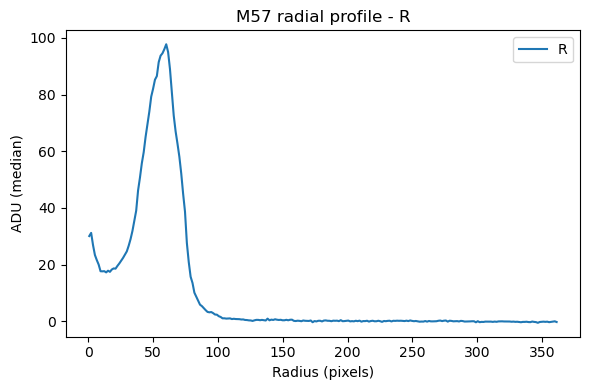

[SAVED] m57_surface_photometry/m57_R_radial_profile.png


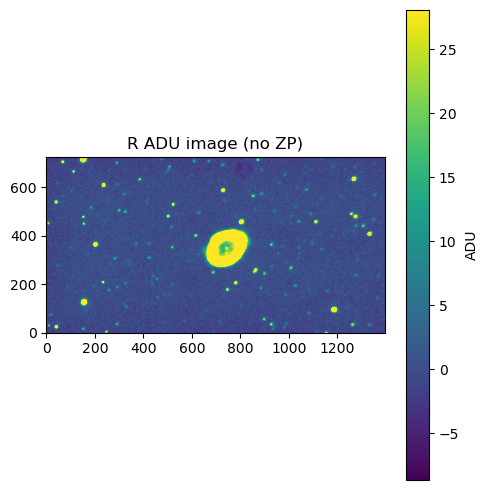

[SAVED] m57_surface_photometry/m57_R_ADU_preview.png
[INFO] Using pixel scale for V: 0.5526 arcsec/pix
[INFO] Zero point for V not found (header detect gave None). Results will be in ADU (or mag/pix if zp provided).
[INFO] V center (x,y) = (744.00, 350.00)


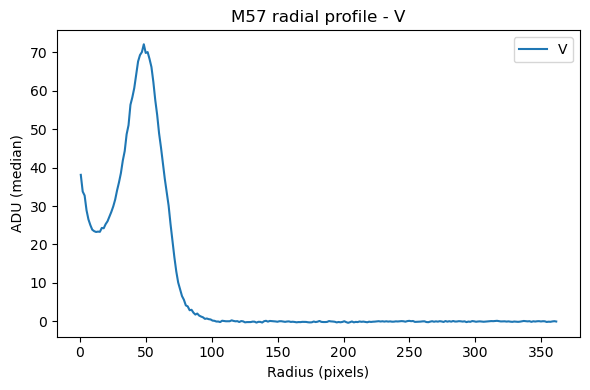

[SAVED] m57_surface_photometry/m57_V_radial_profile.png


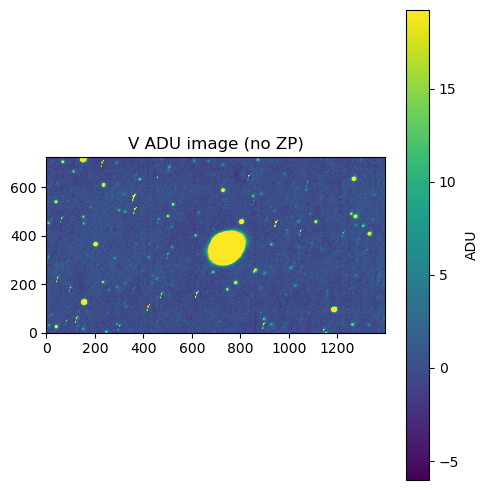

[SAVED] m57_surface_photometry/m57_V_ADU_preview.png
[INFO] Using pixel scale for B: 0.5526 arcsec/pix
[INFO] Zero point for B not found (header detect gave None). Results will be in ADU (or mag/pix if zp provided).
[INFO] B center (x,y) = (744.00, 350.00)


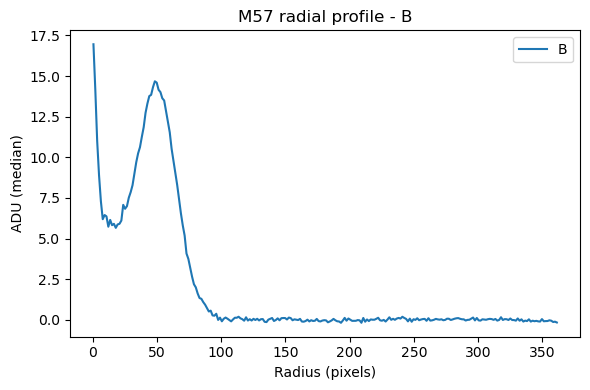

[SAVED] m57_surface_photometry/m57_B_radial_profile.png


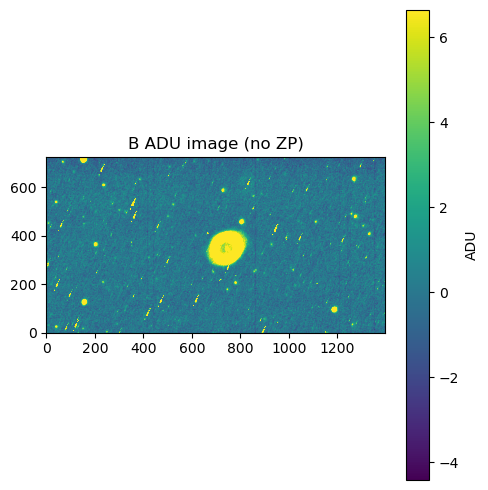

[SAVED] m57_surface_photometry/m57_B_ADU_preview.png
Processing loop finished. Results saved in: m57_surface_photometry


In [290]:
# main processing loop 
results = {}

for filt, p in paths.items():
    if not os.path.exists(p):
        print(f"[WARN] {filt} file not found:", p)
        continue

    data, header, wcs = load_fits(p)
    # estimate header values if manual not provided
    detected_pixscale = guess_pixel_scale_arcsec(header, wcs)
    exptime = guess_exptime(header)
    detected_zp = guess_zeropoint(header)

    final_pixscale = pixel_scale_arcsec if pixel_scale_arcsec is not None else detected_pixscale
    final_zp = zeropoints.get(filt, None) if zeropoints.get(filt, None) is not None else detected_zp

    if final_pixscale is None:
        print(f"[INFO] Pixel scale for {filt} not known (header detect gave {detected_pixscale}). Results will use pixels for distances.")
    else:
        print(f"[INFO] Using pixel scale for {filt}: {final_pixscale:.4f} arcsec/pix")

    if final_zp is None:
        print(f"[INFO] Zero point for {filt} not found (header detect gave {detected_zp}). Results will be in ADU (or mag/pix if zp provided).")
    else:
        print(f"[INFO] Using zeropoint for {filt}: {final_zp:.3f} mag")

    # find center
    # center = find_center(data, method='centroid') - no need to find center, we already have the coords for the center
    center = (744.0, 350.0)  # center of M57 in the images
    print(f"[INFO] {filt} center (x,y) = ({center[0]:.2f}, {center[1]:.2f})")

    # radial profile
    nbins = 250
    maxrad_pix = min(data.shape)/2.0
    r_pix, prof_adu, counts = radial_profile(data, center, nbins=nbins, rmax=maxrad_pix, statistic='median')
    if final_pixscale is not None:
        r_arcsec = r_pix * final_pixscale
    else:
        r_arcsec = None

    # convert to mags if possible
    prof_magpix = None
    prof_mag_arcsec2 = None
    if np.any(prof_adu > 0):
        if final_zp is not None:
            prof_magpix = flux_to_mag_per_pixel(prof_adu, zeropoint=final_zp, exptime=exptime)
            if final_pixscale is not None:
                prof_mag_arcsec2 = magpix_to_mag_arcsec2(prof_magpix, final_pixscale)

    # 2D SB map (if possible)
    sb_map = None
    if final_zp is not None:
        sb_map = flux_to_mag_per_pixel(data, zeropoint=final_zp, exptime=exptime)
        if final_pixscale is not None:
            sb_map = magpix_to_mag_arcsec2(sb_map, final_pixscale)

    # store results
    results[filt] = {
        'path': p,
        'data': data,
        'header': header,
        'wcs': wcs,
        'center': center,
        'r_pix': r_pix,
        'r_arcsec': r_arcsec,
        'prof_adu': prof_adu,
        'prof_magpix': prof_magpix,
        'prof_mag_arcsec2': prof_mag_arcsec2,
        'sb_map': sb_map,
        'pixscale': final_pixscale,
        'exptime': exptime,
        'zeropoint': final_zp,
        'counts': counts
    }

    # quick save: radial profile PNG
    fig, ax = plt.subplots(figsize=(6,4))
    if prof_mag_arcsec2 is not None and r_arcsec is not None:
        ax.plot(r_arcsec, prof_mag_arcsec2, '-', label=f'{filt}')
        ax.set_xlabel('Radius (arcsec)')
        ax.set_ylabel('Surface brightness (mag/arcsec^2)')
        ax.invert_yaxis()
    elif prof_magpix is not None:
        ax.plot(r_pix, prof_magpix, '-', label=f'{filt}')
        ax.set_xlabel('Radius (pixels)')
        ax.set_ylabel('Magnitude (mag/pixel)')
        ax.invert_yaxis()
    else:
        ax.plot(r_pix, prof_adu, '-', label=f'{filt}')
        ax.set_xlabel('Radius (pixels)')
        ax.set_ylabel('ADU (median)')
    ax.set_title(f'M57 radial profile - {filt}')
    ax.legend()
    fig.tight_layout()
    pngname = os.path.join(out_dir, f'm57_{filt}_radial_profile.png')
    fig.savefig(pngname)
    plt.show()
    plt.close(fig)
    print(f'[SAVED] {pngname}')

    # save SB map as FITS and preview PNG if available
    if sb_map is not None:
        # create header for SB map: copy original header and add info
        new_hdr = header.copy()
        new_hdr['HISTORY'] = 'Surface brightness map (mag/pix or mag/arcsec^2)'
        hdu = fits.PrimaryHDU(sb_map, header=new_hdr)
        fitsname = os.path.join(out_dir, f'm57_{filt}_SB_map.fits')
        hdu.writeto(fitsname, overwrite=True)
        print(f'[SAVED] {fitsname}')
        # PNG preview
        img = sb_map.copy()
        finite = np.isfinite(img)
        if finite.sum() > 10:
            vmin, vmax = np.nanpercentile(img[finite], [2,98])
        else:
            vmin, vmax = np.nanmin(img), np.nanmax(img)
        fig, ax = plt.subplots(figsize=(5,5))
        im = ax.imshow(img, origin='lower', vmin=vmin, vmax=vmax)
        cb = fig.colorbar(im, ax=ax)
        cb.set_label('mag/arcsec^2' if final_pixscale is not None else 'mag/pixel')
        ax.set_title(f'{filt} SB map')
        fig.tight_layout()
        pngname = os.path.join(out_dir, f'm57_{filt}_SB_map.png')
        fig.savefig(pngname)
        plt.show()
        plt.close(fig)
        print(f'[SAVED] {pngname}')
    else:
        # save raw ADU image preview
        img = data.copy()
        finite = np.isfinite(img)
        vmin, vmax = np.nanpercentile(img[finite], [2,98]) if finite.sum()>10 else (np.nanmin(img), np.nanmax(img))
        fig, ax = plt.subplots(figsize=(5,5))
        im = ax.imshow(img, origin='lower', vmin=vmin, vmax=vmax)
        fig.colorbar(im, ax=ax).set_label('ADU')
        ax.set_title(f'{filt} ADU image (no ZP)')
        pngname = os.path.join(out_dir, f'm57_{filt}_ADU_preview.png')
        fig.tight_layout()
        fig.savefig(pngname)
        plt.show()
        plt.close(fig)
        print(f'[SAVED] {pngname}')

print('Processing loop finished. Results saved in:', out_dir)

# Surface Magnitude

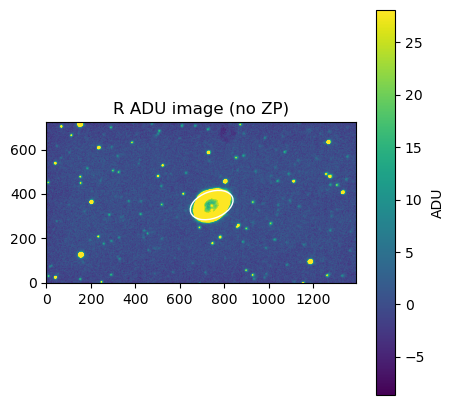

[INFO] Total counts - R filter: 1053435.3620996731
[INFO] Instrumental magnitude - R filter: -11.364
[INFO] Final magnitude (with ZP=20.45) - R filter: 9.086
[INFO] Surface magnitude - R filter: 18.487


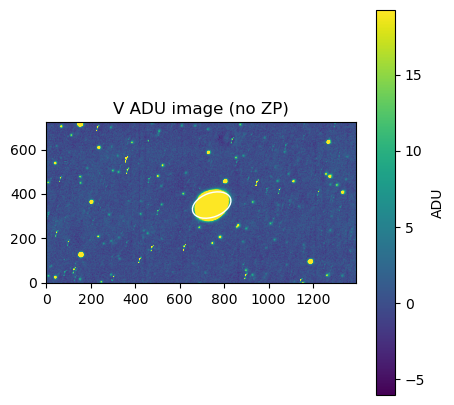

[INFO] Total counts - V filter: 684237.3504179255
[INFO] Instrumental magnitude - V filter: -10.895
[INFO] Final magnitude (with ZP=20.29) - V filter: 9.395
[INFO] Surface magnitude - V filter: 18.795


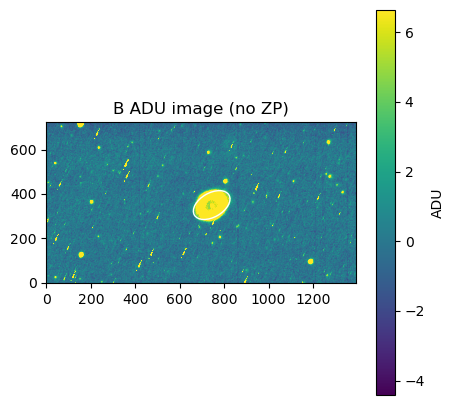

[INFO] Total counts - B filter: 153403.2356713591
[INFO] Instrumental magnitude - B filter: -9.272
[INFO] Final magnitude (with ZP=19.63) - B filter: 10.358
[INFO] Surface magnitude - B filter: 19.759


In [ ]:
# Surface magnitude
center = (744.0, 350.0)
for filt, p in paths.items():
    
    if not os.path.exists(p):
        print(f"[WARN] {filt} file not found:", p)
        continue

    data, header, wcs = load_fits(p)

    img = data.copy()

    finite = np.isfinite(img)
    vmin, vmax = np.nanpercentile(img[finite], [2,98]) if finite.sum()>10 else (np.nanmin(img), np.nanmax(img))
    fig, ax = plt.subplots(figsize=(5,5))
    im = ax.imshow(img, origin='lower', vmin=vmin, vmax=vmax)
    fig.colorbar(im, ax=ax).set_label('ADU')
    ax.set_title(f'{filt} ADU image (no ZP)')

    x0, y0 = center
    if filt == 'R':
        geometry = EllipseGeometry(x0=x0, y0=y0, sma=100, eps=0.4, pa=20.0 * np.pi / 180.0)
    elif filt == 'B':
        geometry = EllipseGeometry(x0=x0, y0=y0, sma=90, eps=0.4, pa=30.0 * np.pi / 180.0) 
    elif filt == 'V':
        geometry = EllipseGeometry(x0=x0, y0=y0, sma=90, eps=0.4, pa=20.0 * np.pi / 180.0)

    aper = EllipticalAperture((geometry.x0, geometry.y0), geometry.sma, geometry.sma * (1 - geometry.eps), geometry.pa)
    plt.imshow(img, origin='lower', vmin=vmin, vmax=vmax)
    aper.plot(color='white')
    plt.show()

    # Calculate Surface Magnitude
    phot_table = aperture_photometry(img, aper)
    total_counts = phot_table['aperture_sum'][0]
    print(f"[INFO] Total counts - {filt} filter: {total_counts}") # total counts inside ellipse

    #Instrumet Magnitude
    inst_mag = -2.5 * np.log10(total_counts / 30) 
    print(f"[INFO] Instrumental magnitude - {filt} filter: {inst_mag:.3f}")

    # Now we need to add the ZP to get the final magnitude
    red_zp = 20.45
    blue_zp = 19.63
    green_zp = 20.29

    if filt == 'R':
        zp = red_zp
    elif filt == 'B':
        zp = blue_zp
    elif filt == 'V':
        zp = green_zp

    final_inst_mag = inst_mag + zp
    print(f"[INFO] Final magnitude (with ZP={zp}) - {filt} filter: {final_inst_mag:.3f}")

    # surface magnitude
    # S=m+2,5log(A)
    area = 5757 # area in arcsec^2 inside the ellipse calculated with pixel scale of 0.55 arcsec/pix
    surf_mag = final_inst_mag + 2.5 * np.log10(area)
    print(f"[INFO] Surface magnitude - {filt} filter: {surf_mag:.3f}")

[INFO] Fitted 59 isophotes for R filter
       sma               intens            intens_err     ... niter stop_code
                                                          ...                
------------------ ------------------ ------------------- ... ----- ---------
               0.0 39.304292641549864                 0.0 ...     0         0
0.5289350131014788 36.385274567720735 0.09309525067501606 ...    10         0
0.5818285144116268 36.072076373062814 0.09808426860297283 ...    10         0
0.6400113658527895  35.74482664545272 0.10579367989123234 ...    10         0
0.7040125024380685  35.41140660596116 0.11189630683847344 ...    10         0
0.7744137526818753 35.063823172832436 0.12044533924531312 ...    10         0
0.8518551279500629  34.71638004319661  0.1284577716888255 ...    10         0
0.9370406407450692  34.23458784554161  0.1279504055441336 ...    10         0
1.0307447048195761 33.813116331637026 0.13009767863239513 ...    10         0
               ...      

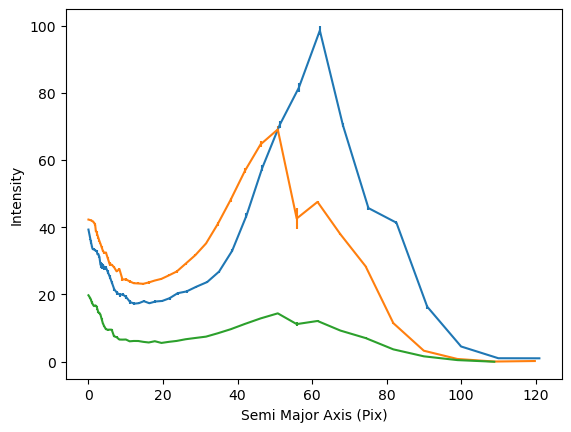

In [325]:
# Isophote fitting
for filt, p in paths.items():
    
    if not os.path.exists(p):
        print(f"[WARN] {filt} file not found:", p)
        continue

    data, header, wcs = load_fits(p)

    img = data.copy()
    x0, y0 = center
    if filt == 'R':
        geometry = EllipseGeometry(x0=x0, y0=y0, sma=100, eps=0.4, pa=20.0 * np.pi / 180.0)
    elif filt == 'B':
        geometry = EllipseGeometry(x0=x0, y0=y0, sma=90, eps=0.4, pa=30.0 * np.pi / 180.0) 
    elif filt == 'V':
        geometry = EllipseGeometry(x0=x0, y0=y0, sma=90, eps=0.4, pa=20.0 * np.pi / 180.0)

    ellipse = Ellipse(img, geometry)
    isolist = ellipse.fit_image() 
    print(f"[INFO] Fitted {len(isolist)} isophotes for {filt} filter")
    print(isolist.to_table())
    
    plt.errorbar(isolist.sma,isolist.intens,yerr=isolist.int_err)
    plt.xlabel("Semi Major Axis (Pix)")
    plt.ylabel("Intensity")

# Combined plot of radial profiles (all filters)

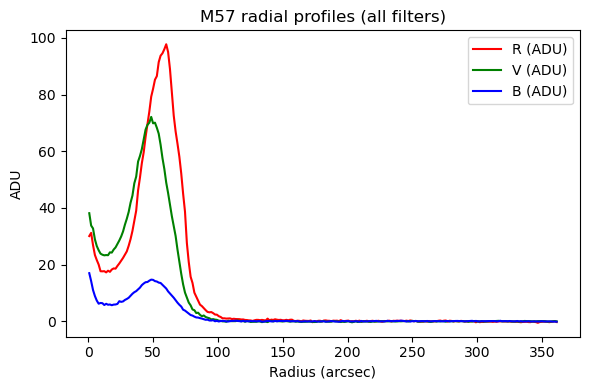

[SAVED] m57_surface_photometry/m57_all_filters_radial_profiles.png


In [329]:
# this is the combined plot of radial profiles (all filters)
fig, ax = plt.subplots(figsize=(6,4))
any_arcsec = any((res.get('r_arcsec') is not None) for res in results.values())

# define colors for specific filters
filter_colors = {
    'R': 'red',
    'V': 'green',
    'B': 'blue'
}

for filt, res in results.items():
    color = filter_colors.get(filt, None)  # default color if not specified
    if res['prof_mag_arcsec2'] is not None and res['r_arcsec'] is not None:
        ax.plot(res['r_arcsec'], res['prof_mag_arcsec2'], label=filt, color=color)
    elif res['prof_magpix'] is not None:
        ax.plot(res['r_pix'], res['prof_magpix'], label=filt + ' (mag/pix)', color=color)
    else:
        ax.plot(res['r_pix'], res['prof_adu'], label=filt + ' (ADU)', color=color)
if any_arcsec:
    ax.set_xlabel('Radius (arcsec)')
else:
    ax.set_xlabel('Radius (pixels)')
ax.set_ylabel('ADU')
ax.legend()
ax.set_title('M57 radial profiles (all filters)')
fig.tight_layout()
outname = os.path.join(out_dir, 'm57_all_filters_radial_profiles.png')
fig.savefig(outname)
plt.show()
plt.close(fig)
print('[SAVED]', outname)